# MobileNet + Data Augmentation

**NOTE:** The results in this notebook are similar to those shown in the book but are not 100% the same. Because neural networks are initialized with random numbers, each training session will give slightly different results.

In [1]:
import os
import numpy as np

from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import *
from keras import optimizers, callbacks
import keras.backend as K

%matplotlib inline
import matplotlib.pyplot as plt

## Load the MobileNet feature extractor

In [2]:
image_width = 224
image_height = 224

In [3]:
from keras.applications.mobilenet import MobileNet

base_model = MobileNet(input_shape=(image_height, image_width, 3), 
                       include_top=False, weights="imagenet", 
                       pooling=None)

In [4]:
base_model.summary()

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                         

                                                                 
 conv_pw_8_bn (BatchNormaliz  (None, 14, 14, 512)      2048      
 ation)                                                          
                                                                 
 conv_pw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_dw_9 (DepthwiseConv2D)  (None, 14, 14, 512)      4608      
                                                                 
 conv_dw_9_bn (BatchNormaliz  (None, 14, 14, 512)      2048      
 ation)                                                          
                                                                 
 conv_dw_9_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_pw_9 (Conv2D)          (None, 14, 14, 512)       262144    
                                                                 
 conv_pw_9

In [6]:
for layer in base_model.layers:
    if len(layer.non_trainable_weights) > 0:
        print(f"{layer.name}: {len(layer.non_trainable_weights)} non-trainable params")

conv1_bn: 2 non-trainable params
conv_dw_1_bn: 2 non-trainable params
conv_pw_1_bn: 2 non-trainable params
conv_dw_2_bn: 2 non-trainable params
conv_pw_2_bn: 2 non-trainable params
conv_dw_3_bn: 2 non-trainable params
conv_pw_3_bn: 2 non-trainable params
conv_dw_4_bn: 2 non-trainable params
conv_pw_4_bn: 2 non-trainable params
conv_dw_5_bn: 2 non-trainable params
conv_pw_5_bn: 2 non-trainable params
conv_dw_6_bn: 2 non-trainable params
conv_pw_6_bn: 2 non-trainable params
conv_dw_7_bn: 2 non-trainable params
conv_pw_7_bn: 2 non-trainable params
conv_dw_8_bn: 2 non-trainable params
conv_pw_8_bn: 2 non-trainable params
conv_dw_9_bn: 2 non-trainable params
conv_pw_9_bn: 2 non-trainable params
conv_dw_10_bn: 2 non-trainable params
conv_pw_10_bn: 2 non-trainable params
conv_dw_11_bn: 2 non-trainable params
conv_pw_11_bn: 2 non-trainable params
conv_dw_12_bn: 2 non-trainable params
conv_pw_12_bn: 2 non-trainable params
conv_dw_13_bn: 2 non-trainable params
conv_pw_13_bn: 2 non-trainable para

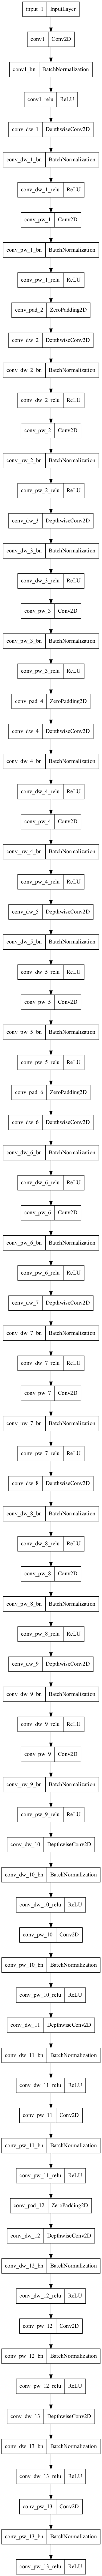

In [7]:
from keras.utils import plot_model
plot_model(base_model, to_file="mobilenet.png")

## Add a classifier on top

In [8]:
num_classes = 20

In [9]:
top_model = Sequential()
top_model.add(base_model)
top_model.add(GlobalAveragePooling2D())
top_model.add(Dense(num_classes))
top_model.add(Activation("softmax"))

In [10]:
for layer in base_model.layers:
    layer.trainable = False

In [11]:
top_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenet_1.00_224 (Functio  (None, 7, 7, 1024)       3228864   
 nal)                                                            
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 20)                20500     
                                                                 
 activation (Activation)     (None, 20)                0         
                                                                 
Total params: 3,249,364
Trainable params: 20,500
Non-trainable params: 3,228,864
_________________________________________________________________


In [13]:
top_model.compile(loss="categorical_crossentropy",
                  optimizer=optimizers.Adam(learning_rate=1e-3),
                  metrics=["accuracy"])

## Data augmentation

In [14]:
from keras.applications.mobilenet import preprocess_input

train_datagen = ImageDataGenerator(
                    rotation_range=40,
                    width_shift_range=0.2,
                    height_shift_range=0.2,
                    shear_range=0.2,
                    zoom_range=0.2,
                    channel_shift_range=0.2,
                    horizontal_flip=True,
                    fill_mode="nearest",
                    preprocessing_function=preprocess_input)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [15]:
images_dir = "snacks/"
train_data_dir = images_dir + "train/"
val_data_dir = images_dir + "val/"
test_data_dir = images_dir + "test/"

In [16]:
batch_size = 64

train_generator = train_datagen.flow_from_directory(
                    train_data_dir,
                    target_size=(image_width, image_height),
                    batch_size=batch_size,
                    class_mode="categorical",
                    shuffle=True)

val_generator = val_datagen.flow_from_directory(
                    val_data_dir,
                    target_size=(image_width, image_height),
                    batch_size=batch_size,
                    class_mode="categorical",
                    shuffle=False)

test_generator = test_datagen.flow_from_directory(
                    test_data_dir,
                    target_size=(image_width, image_height),
                    batch_size=batch_size,
                    class_mode="categorical",
                    shuffle=False)

Found 4838 images belonging to 20 classes.
Found 955 images belonging to 20 classes.
Found 952 images belonging to 20 classes.


In [17]:
import warnings
warnings.filterwarnings("ignore")

## Training the classifier

In [26]:
checkpoint_dir = "checkpoints/"
checkpoint_name = checkpoint_dir + "multisnacks-{val_loss:.4f}-{val_accuracy:.4f}.hdf5"

In [27]:
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

In [28]:
def create_callbacks():
    return [
        callbacks.EarlyStopping(monitor="val_accuracy", patience=10, verbose=1),

        callbacks.ModelCheckpoint(checkpoint_name, monitor="val_accuracy", 
                                  verbose=1, save_best_only=True),
    ]

my_callbacks = create_callbacks()

In [29]:
histories = []

In [30]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=10,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/10
76/76 [==============================] - ETA: 0s - loss: 1.0566 - accuracy: 0.6875
Epoch 1: val_accuracy improved from -inf to 0.69948, saving model to checkpoints/multisnacks-1.0405-0.6995.hdf5
76/76 [==============================] - 25s 325ms/step - loss: 1.0566 - accuracy: 0.6875 - val_loss: 1.0405 - val_accuracy: 0.6995
Epoch 2/10
76/76 [==============================] - ETA: 0s - loss: 0.9344 - accuracy: 0.7327
Epoch 2: val_accuracy improved from 0.69948 to 0.71937, saving model to checkpoints/multisnacks-0.9927-0.7194.hdf5
76/76 [==============================] - 26s 332ms/step - loss: 0.9344 - accuracy: 0.7327 - val_loss: 0.9927 - val_accuracy: 0.7194
Epoch 3/10
76/76 [==============================] - ETA: 0s - loss: 0.8622 - accuracy: 0.7437
Epoch 3: val_accuracy improved from 0.71937 to 0.73194, saving model to checkpoints/multisnacks-0.9300-0.7319.hdf5
76/76 [==============================] - 26s 331ms/step - loss: 0.8622 - accuracy: 0.7437 - val_loss: 0.9300 - v

In [33]:
def combine_histories():
    history = { "loss": [], "val_loss": [], "accuracy": [], "val_accuracy": [] }
    for h in histories:
        for k in history.keys():
            history[k] += h.history[k]
    return history

In [34]:
history = combine_histories()

In [35]:
def plot_loss(history):
    fig = plt.figure(figsize=(10, 6))
    plt.plot(history["loss"])
    plt.plot(history["val_loss"])
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train", "Validation"])
    plt.show()

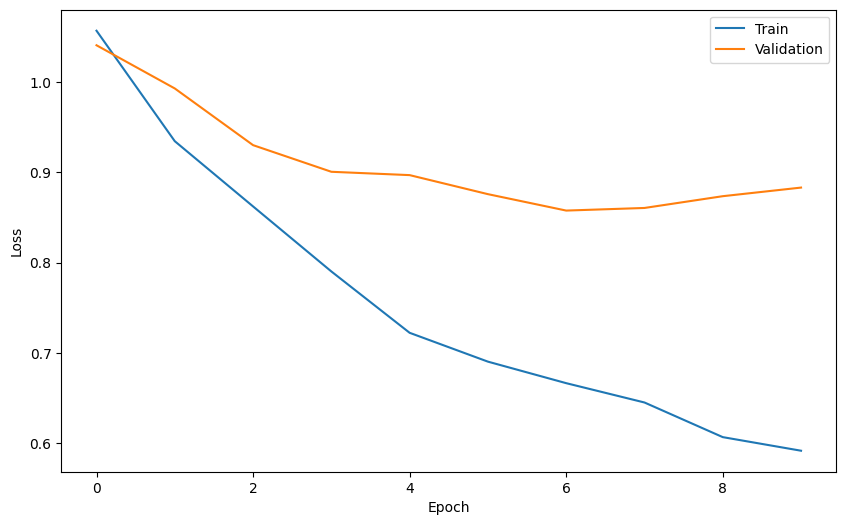

In [36]:
plot_loss(history)

In [40]:
def plot_accuracy(history):
    fig = plt.figure(figsize=(10, 6))
    plt.plot(history["accuracy"])
    plt.plot(history["val_accuracy"])
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(["Train", "Validation"])
    plt.show()

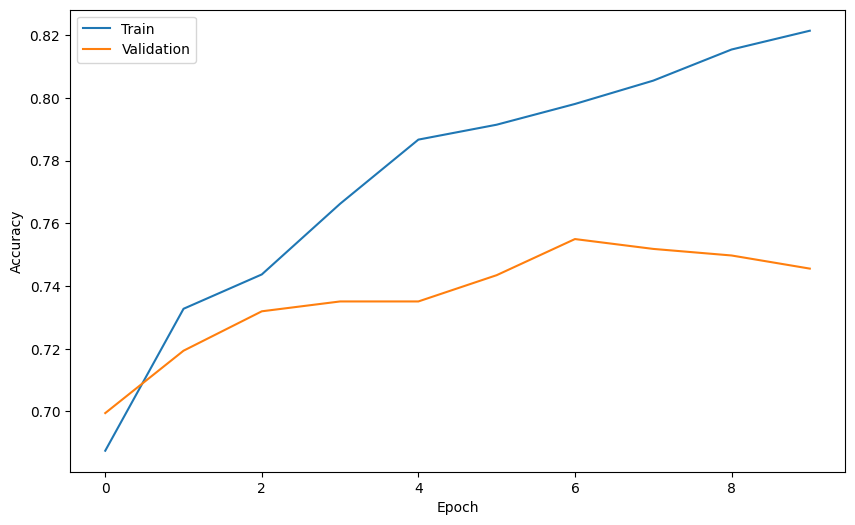

In [41]:
plot_accuracy(history)

## Fine-tuning the feature extractor

In [42]:
for layer in base_model.layers:
    layer.trainable = True

top_model.compile(loss="categorical_crossentropy",
                  optimizer=optimizers.Adam(lr=1e-4),
                  metrics=["accuracy"])    

In [43]:
top_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenet_1.00_224 (Functio  (None, 7, 7, 1024)       3228864   
 nal)                                                            
                                                                 
 global_average_pooling2d (G  (None, 1024)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 20)                20500     
                                                                 
 activation (Activation)     (None, 20)                0         
                                                                 
Total params: 3,249,364
Trainable params: 3,227,476
Non-trainable params: 21,888
_________________________________________________________________


In [44]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=10,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/10
76/76 [==============================] - ETA: 0s - loss: 0.7034 - accuracy: 0.7823
Epoch 1: val_accuracy did not improve from 0.75497
76/76 [==============================] - 93s 1s/step - loss: 0.7034 - accuracy: 0.7823 - val_loss: 0.9343 - val_accuracy: 0.7267
Epoch 2/10
76/76 [==============================] - ETA: 0s - loss: 0.4589 - accuracy: 0.8617
Epoch 2: val_accuracy improved from 0.75497 to 0.76021, saving model to checkpoints/multisnacks-0.8252-0.7602.hdf5
76/76 [==============================] - 94s 1s/step - loss: 0.4589 - accuracy: 0.8617 - val_loss: 0.8252 - val_accuracy: 0.7602
Epoch 3/10
76/76 [==============================] - ETA: 0s - loss: 0.3485 - accuracy: 0.8979
Epoch 3: val_accuracy did not improve from 0.76021
76/76 [==============================] - 101s 1s/step - loss: 0.3485 - accuracy: 0.8979 - val_loss: 0.8611 - val_accuracy: 0.7445
Epoch 4/10
76/76 [==============================] - ETA: 0s - loss: 0.2850 - accuracy: 0.9184
Epoch 4: val_accura

In [45]:
K.set_value(top_model.optimizer.lr, K.get_value(top_model.optimizer.lr) / 3)

In [46]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=5,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/5
76/76 [==============================] - ETA: 0s - loss: 0.0773 - accuracy: 0.9862
Epoch 1: val_accuracy improved from 0.78848 to 0.79476, saving model to checkpoints/multisnacks-0.7217-0.7948.hdf5
76/76 [==============================] - 92s 1s/step - loss: 0.0773 - accuracy: 0.9862 - val_loss: 0.7217 - val_accuracy: 0.7948
Epoch 2/5
76/76 [==============================] - ETA: 0s - loss: 0.0712 - accuracy: 0.9874
Epoch 2: val_accuracy improved from 0.79476 to 0.80105, saving model to checkpoints/multisnacks-0.7010-0.8010.hdf5
76/76 [==============================] - 93s 1s/step - loss: 0.0712 - accuracy: 0.9874 - val_loss: 0.7010 - val_accuracy: 0.8010
Epoch 3/5
76/76 [==============================] - ETA: 0s - loss: 0.0735 - accuracy: 0.9841
Epoch 3: val_accuracy did not improve from 0.80105
76/76 [==============================] - 99s 1s/step - loss: 0.0735 - accuracy: 0.9841 - val_loss: 0.6984 - val_accuracy: 0.7969
Epoch 4/5
76/76 [==============================] - ET

In [47]:
K.set_value(top_model.optimizer.lr, K.get_value(top_model.optimizer.lr) / 3)

In [48]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=5,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/5
76/76 [==============================] - ETA: 0s - loss: 0.0562 - accuracy: 0.9888
Epoch 1: val_accuracy improved from 0.80105 to 0.80314, saving model to checkpoints/multisnacks-0.6840-0.8031.hdf5
76/76 [==============================] - 93s 1s/step - loss: 0.0562 - accuracy: 0.9888 - val_loss: 0.6840 - val_accuracy: 0.8031
Epoch 2/5
76/76 [==============================] - ETA: 0s - loss: 0.0556 - accuracy: 0.9903
Epoch 2: val_accuracy improved from 0.80314 to 0.80524, saving model to checkpoints/multisnacks-0.6821-0.8052.hdf5
76/76 [==============================] - 92s 1s/step - loss: 0.0556 - accuracy: 0.9903 - val_loss: 0.6821 - val_accuracy: 0.8052
Epoch 3/5
76/76 [==============================] - ETA: 0s - loss: 0.0538 - accuracy: 0.9903
Epoch 3: val_accuracy improved from 0.80524 to 0.80628, saving model to checkpoints/multisnacks-0.6823-0.8063.hdf5
76/76 [==============================] - 94s 1s/step - loss: 0.0538 - accuracy: 0.9903 - val_loss: 0.6823 - val_accura

In [49]:
history = combine_histories()

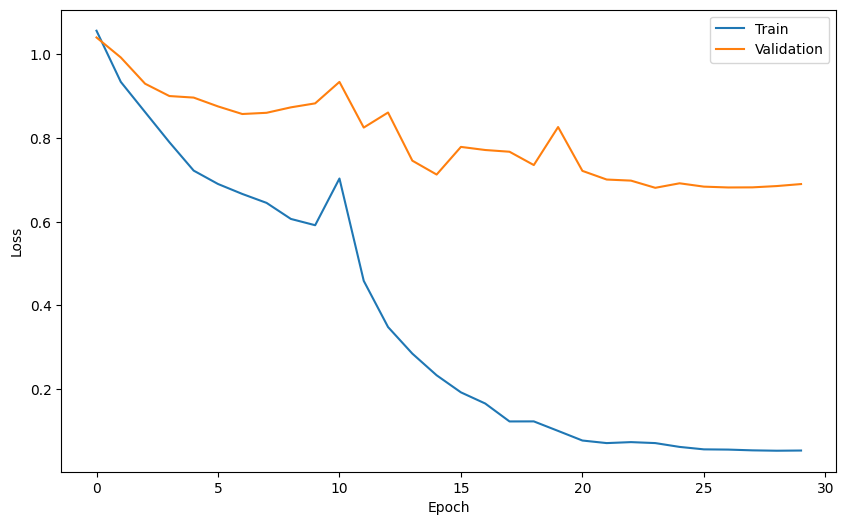

In [50]:
plot_loss(history)

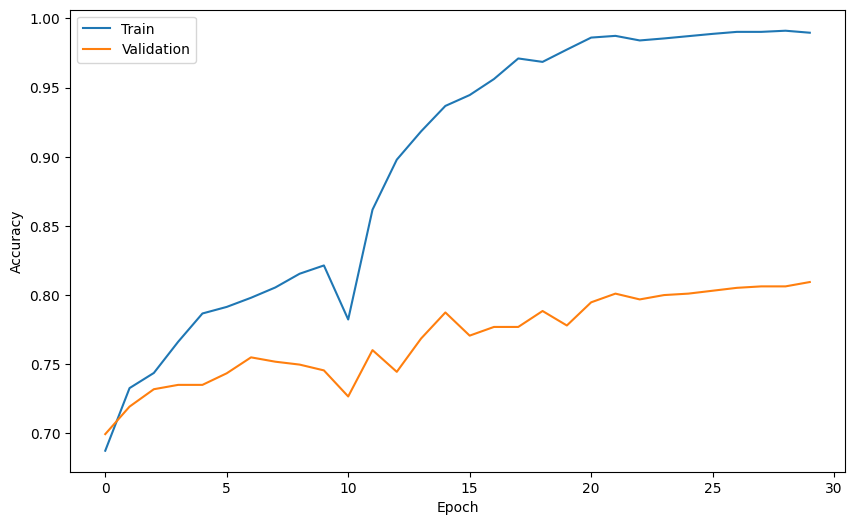

In [51]:
plot_accuracy(history)

In [52]:
top_model.evaluate_generator(test_generator, steps=len(test_generator))

[0.5762373208999634, 0.8371848464012146]

## Regularization and dropout

In [53]:
base_model = MobileNet(input_shape=(image_height, image_width, 3), 
                       include_top=False, weights="imagenet", 
                       pooling=None)

In [54]:
from keras import regularizers

top_model = Sequential()
top_model.add(base_model)
top_model.add(GlobalAveragePooling2D())
top_model.add(Dropout(0.5))
top_model.add(Dense(num_classes, kernel_regularizer=regularizers.l2(0.01)))
top_model.add(Activation("softmax"))

In [55]:
for layer in base_model.layers:
    layer.trainable = False

top_model.compile(loss="categorical_crossentropy",
                  optimizer=optimizers.Adam(lr=1e-3),
                  metrics=["accuracy"])

In [56]:
my_callbacks = create_callbacks()

In [57]:
histories = []

In [58]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=10,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/10
76/76 [==============================] - ETA: 0s - loss: 3.5003 - accuracy: 0.1842
Epoch 1: val_accuracy improved from -inf to 0.52251, saving model to checkpoints/multisnacks-2.0295-0.5225.hdf5
76/76 [==============================] - 26s 334ms/step - loss: 3.5003 - accuracy: 0.1842 - val_loss: 2.0295 - val_accuracy: 0.5225
Epoch 2/10
76/76 [==============================] - ETA: 0s - loss: 2.2765 - accuracy: 0.4291
Epoch 2: val_accuracy improved from 0.52251 to 0.62827, saving model to checkpoints/multisnacks-1.5879-0.6283.hdf5
76/76 [==============================] - 26s 341ms/step - loss: 2.2765 - accuracy: 0.4291 - val_loss: 1.5879 - val_accuracy: 0.6283
Epoch 3/10
76/76 [==============================] - ETA: 0s - loss: 1.8805 - accuracy: 0.5308
Epoch 3: val_accuracy improved from 0.62827 to 0.69529, saving model to checkpoints/multisnacks-1.3790-0.6953.hdf5
76/76 [==============================] - 26s 329ms/step - loss: 1.8805 - accuracy: 0.5308 - val_loss: 1.3790 - v

In [59]:
for layer in base_model.layers:
    layer.trainable = True

top_model.compile(loss="categorical_crossentropy",
                  optimizer=optimizers.Adam(lr=1e-4),
                  metrics=["accuracy"])    

In [60]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=10,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/10
76/76 [==============================] - ETA: 0s - loss: 1.2626 - accuracy: 0.6866
Epoch 1: val_accuracy did not improve from 0.74450
76/76 [==============================] - 93s 1s/step - loss: 1.2626 - accuracy: 0.6866 - val_loss: 1.1090 - val_accuracy: 0.7204
Epoch 2/10
76/76 [==============================] - ETA: 0s - loss: 1.0119 - accuracy: 0.7606
Epoch 2: val_accuracy improved from 0.74450 to 0.74974, saving model to checkpoints/multisnacks-0.9998-0.7497.hdf5
76/76 [==============================] - 93s 1s/step - loss: 1.0119 - accuracy: 0.7606 - val_loss: 0.9998 - val_accuracy: 0.7497
Epoch 3/10
76/76 [==============================] - ETA: 0s - loss: 0.8728 - accuracy: 0.7966
Epoch 3: val_accuracy improved from 0.74974 to 0.76126, saving model to checkpoints/multisnacks-0.9843-0.7613.hdf5
76/76 [==============================] - 94s 1s/step - loss: 0.8728 - accuracy: 0.7966 - val_loss: 0.9843 - val_accuracy: 0.7613
Epoch 4/10
76/76 [==============================] 

In [61]:
K.set_value(top_model.optimizer.lr, K.get_value(top_model.optimizer.lr) / 3)

In [62]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=5,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/5
76/76 [==============================] - ETA: 0s - loss: 0.4409 - accuracy: 0.9326
Epoch 1: val_accuracy improved from 0.82094 to 0.82932, saving model to checkpoints/multisnacks-0.7656-0.8293.hdf5
76/76 [==============================] - 92s 1s/step - loss: 0.4409 - accuracy: 0.9326 - val_loss: 0.7656 - val_accuracy: 0.8293
Epoch 2/5
76/76 [==============================] - ETA: 0s - loss: 0.4296 - accuracy: 0.9351
Epoch 2: val_accuracy improved from 0.82932 to 0.83246, saving model to checkpoints/multisnacks-0.7509-0.8325.hdf5
76/76 [==============================] - 89s 1s/step - loss: 0.4296 - accuracy: 0.9351 - val_loss: 0.7509 - val_accuracy: 0.8325
Epoch 3/5
76/76 [==============================] - ETA: 0s - loss: 0.4077 - accuracy: 0.9432
Epoch 3: val_accuracy did not improve from 0.83246
76/76 [==============================] - 91s 1s/step - loss: 0.4077 - accuracy: 0.9432 - val_loss: 0.7429 - val_accuracy: 0.8293
Epoch 4/5
76/76 [==============================] - ET

In [63]:
K.set_value(top_model.optimizer.lr, K.get_value(top_model.optimizer.lr) / 3)

In [64]:
histories.append(top_model.fit_generator(train_generator, 
                              steps_per_epoch=len(train_generator),
                              epochs=5,
                              callbacks=my_callbacks,
                              validation_data=val_generator,
                              validation_steps=len(val_generator),
                              workers=8))

Epoch 1/5
76/76 [==============================] - ETA: 0s - loss: 0.3706 - accuracy: 0.9523
Epoch 1: val_accuracy improved from 0.83455 to 0.84084, saving model to checkpoints/multisnacks-0.7393-0.8408.hdf5
76/76 [==============================] - 91s 1s/step - loss: 0.3706 - accuracy: 0.9523 - val_loss: 0.7393 - val_accuracy: 0.8408
Epoch 2/5
76/76 [==============================] - ETA: 0s - loss: 0.3666 - accuracy: 0.9574
Epoch 2: val_accuracy did not improve from 0.84084
76/76 [==============================] - 91s 1s/step - loss: 0.3666 - accuracy: 0.9574 - val_loss: 0.7405 - val_accuracy: 0.8377
Epoch 3/5
76/76 [==============================] - ETA: 0s - loss: 0.3719 - accuracy: 0.9551
Epoch 3: val_accuracy did not improve from 0.84084
76/76 [==============================] - 90s 1s/step - loss: 0.3719 - accuracy: 0.9551 - val_loss: 0.7420 - val_accuracy: 0.8366
Epoch 4/5
76/76 [==============================] - ETA: 0s - loss: 0.3717 - accuracy: 0.9541
Epoch 4: val_accuracy di

In [65]:
history = combine_histories()

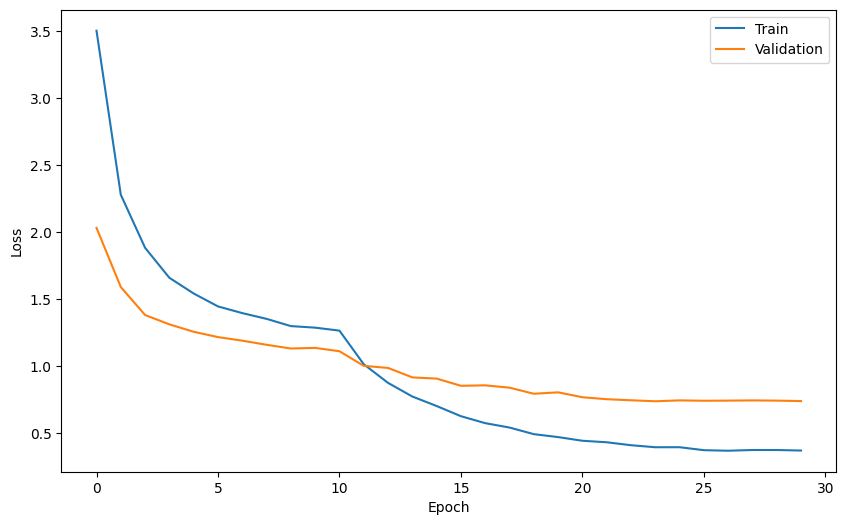

In [66]:
plot_loss(history)

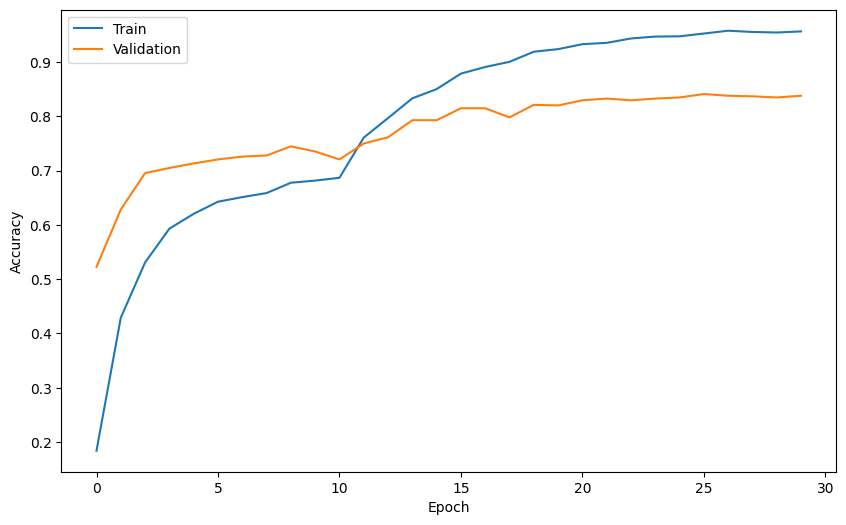

In [67]:
plot_accuracy(history)

## Evaluate on the best model

In [68]:
from keras.models import load_model

best_model = load_model(checkpoint_dir + "multisnacks-0.7393-0.8408.hdf5")

In [69]:
best_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenet_1.00_224 (Functio  (None, 7, 7, 1024)       3228864   
 nal)                                                            
                                                                 
 global_average_pooling2d_1   (None, 1024)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 20)                20500     
                                                                 
 activation_1 (Activation)   (None, 20)                0         
                                                                 
Total params: 3,249,364
Trainable params: 3,227,476
No

Evaluate on the test data:

In [70]:
best_model.evaluate_generator(test_generator, steps=len(test_generator))

[0.6767977476119995, 0.868697464466095]

In [71]:
test_generator.reset()
probabilities = best_model.predict_generator(test_generator, steps=len(test_generator))
predicted_labels = np.argmax(probabilities, axis=-1)

In [72]:
target_labels = test_generator.classes

In [73]:
from sklearn import metrics
conf = metrics.confusion_matrix(target_labels, predicted_labels)

In [80]:
# import seaborn as sns

# def plot_confusion_matrix(conf, labels, figsize=(8, 8)):
#     fig = plt.figure(figsize=figsize)
#     heatmap = sns.heatmap(conf, annot=True, fmt="d")
#     heatmap.xaxis.set_ticklabels(labels, rotation=45, ha="right", fontsize=12)
#     heatmap.yaxis.set_ticklabels(labels, rotation=0, ha="right", fontsize=12)
#     plt.xlabel("Predicted label", fontsize=12)
#     plt.ylabel("True label", fontsize=12)
#     plt.show()

In [81]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(conf_matrix, labels, figsize=(8, 8), cmap=plt.cm.Blues):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(conf_matrix, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(labels)),
        yticks=np.arange(len(labels)),
        xticklabels=labels,
        yticklabels=labels,
        xlabel='Predicted label',
        ylabel='True label',
        title='Confusion Matrix'
    )

    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Print numbers in each cell
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(j, i, format(conf_matrix[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if conf_matrix[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

In [82]:
labels = [""] * num_classes
for k, v in test_generator.class_indices.items():
    labels[v] = k

In [84]:
from sklearn.metrics import confusion_matrix
conf = confusion_matrix(target_labels, predicted_labels)

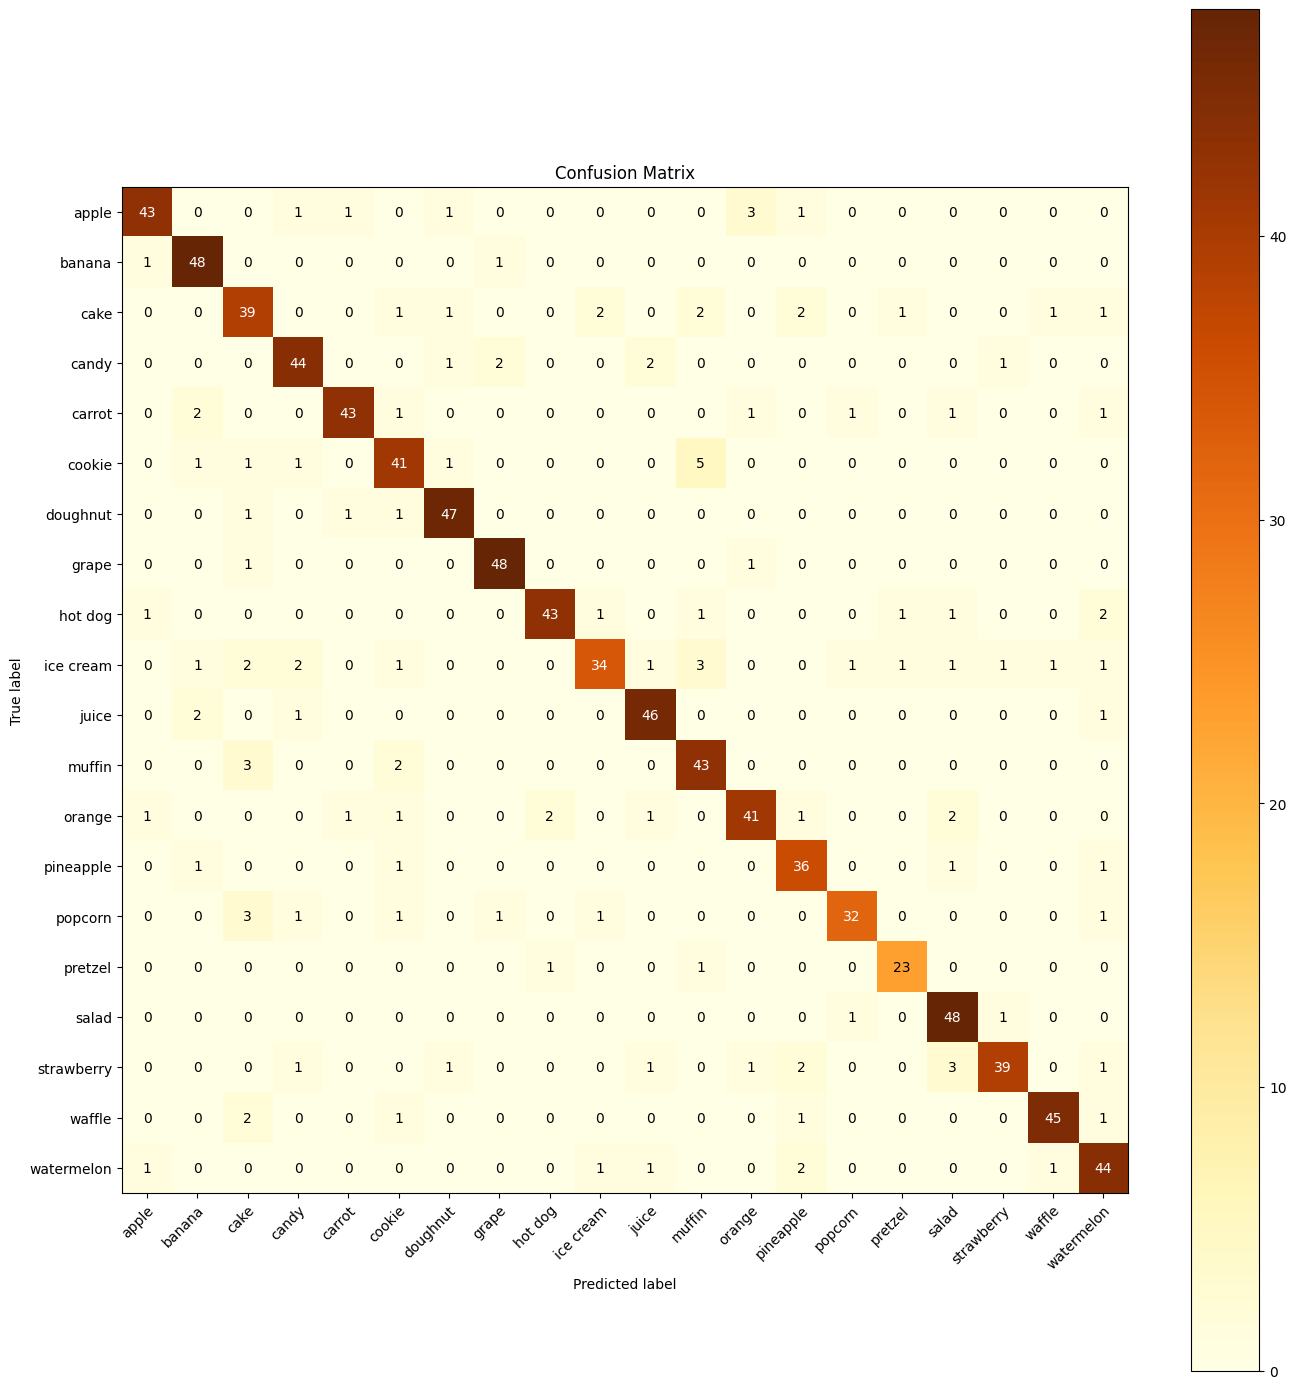

In [92]:
plot_confusion_matrix(conf, labels, figsize=(14, 14), cmap='YlOrBr')

In [93]:
print(metrics.classification_report(target_labels, predicted_labels, target_names=labels))

              precision    recall  f1-score   support

       apple       0.91      0.86      0.89        50
      banana       0.87      0.96      0.91        50
        cake       0.75      0.78      0.76        50
       candy       0.86      0.88      0.87        50
      carrot       0.93      0.86      0.90        50
      cookie       0.80      0.82      0.81        50
    doughnut       0.90      0.94      0.92        50
       grape       0.92      0.96      0.94        50
     hot dog       0.93      0.86      0.90        50
   ice cream       0.87      0.68      0.76        50
       juice       0.88      0.92      0.90        50
      muffin       0.78      0.90      0.83        48
      orange       0.87      0.82      0.85        50
   pineapple       0.80      0.90      0.85        40
     popcorn       0.91      0.80      0.85        40
     pretzel       0.88      0.92      0.90        25
       salad       0.84      0.96      0.90        50
  strawberry       0.93    

Compute precision and recall by hand:

In [94]:
# Get the class index for pineapple
idx = test_generator.class_indices["pineapple"]

# Find how many images were predicted to be pineapple
total_predicted = np.sum(predicted_labels == idx)

# Find how many images really are pineapple (true positives)
correct = conf[idx, idx]

# The precision is then the true positives divided by
# the true + false positives
precision = correct / total_predicted
print(precision)

0.8


In [95]:
# Get the class index for ice cream
idx = test_generator.class_indices["ice cream"]

# Find how many images are supposed to be ice cream
total_expected = np.sum(target_labels == idx)

# How many ice cream images did we find?
correct = conf[idx, idx]

# The recall is then the true positives divided by
# the true positives + false negatives
recall = correct / total_expected
print(recall)

0.68


What are the "most wrong" predictions?

In [96]:
# Find for which images the predicted class is wrong
wrong_images = np.where(predicted_labels != target_labels)[0]

# For every prediction, find the largest probability value;
# this is the probability of the winning class for this image
probs_max = np.max(probabilities, axis=-1)

# Sort the probabilities from the wrong images from low to high
idx = np.argsort(probs_max[wrong_images])

# Reverse the order (high to low), and keep the 5 highest ones
idx = idx[::-1][:5]

# Get the indices of the images with the worst predictions
worst_predictions = wrong_images[idx]

index2class = {v:k for k,v in test_generator.class_indices.items()}

for i in worst_predictions:
    print("%s was predicted as '%s' %.4f\n" % (
        test_generator.filenames[i],
        index2class[predicted_labels[i]],
        probs_max[i]
    ))

strawberry/09d140146c09b309.jpg was predicted as 'salad' 0.9988

muffin/3b25998aac3f7ab4.jpg was predicted as 'cake' 0.9979

apple/671292276d92cee4.jpg was predicted as 'pineapple' 0.9953

orange/36bcc5ef734dad83.jpg was predicted as 'salad' 0.9952

carrot/4990e82cd005a1af.jpg was predicted as 'banana' 0.9933



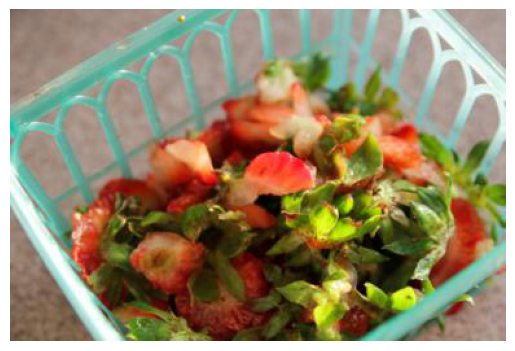

In [98]:
from tensorflow.keras.utils import load_img
import matplotlib.pyplot as plt

img_path = test_data_dir + test_generator.filenames[worst_predictions[0]]
img = load_img(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

## Export to Core ML

In [99]:
import coremltools

In [100]:
labels = ["apple", "banana", "cake", "candy", "carrot", "cookie", 
          "doughnut", "grape", "hot dog", "ice cream", "juice", 
          "muffin", "orange", "pineapple", "popcorn", "pretzel",
          "salad", "strawberry", "waffle", "watermelon"]

In [102]:
#OLD:
# coreml_model = coremltools.converters.keras.convert(
#     best_model,
#     input_names="image",
#     image_input_names="image",
#     output_names="labelProbability",
#     predicted_feature_name="label",
#     red_bias=-1,
#     green_bias=-1,
#     blue_bias=-1,
#     image_scale=2/255.0,
#     class_labels=labels)

In [114]:
#OLD:# import coremltools as ct

# input_name = best_model.input.name.split(":")[0]
# input_shape = tuple(dim if dim is not None else 1 for dim in best_model.input_shape)

# coreml_model = ct.convert(
#     best_model,
#     inputs=[ct.ImageType(name=input_name,
#                          shape=input_shape,
#                          scale=2/255.0,
#                          bias=[-1, -1, -1])],
#     classifier_config=ct.ClassifierConfig(class_labels=labels, predicted_feature_name="label")
# )

In [ ]:
#OLD:
# coreml_model.author = "Your Name Here"
# coreml_model.license = "Public Domain"
# coreml_model.short_description = "Image classifier for 20 different types of snacks"

# coreml_model.input_description["mobilenet_1_00_224_input"] = "Input image"
# coreml_model.output_description["labelProbability"]= "Prediction probabilities"
# coreml_model.output_description["label"]= "Class label of top prediction"

In [116]:
print(coreml_model.get_spec().description)

input {
  name: "mobilenet_1_00_224_input"
  shortDescription: "Input image"
  type {
    imageType {
      width: 224
      height: 224
      colorSpace: RGB
    }
  }
}
output {
  name: "label"
  shortDescription: "Top predicted class label"
  type {
    stringType {
    }
  }
}
output {
  name: "label_probs"
  shortDescription: "Prediction probabilities for each class"
  type {
    dictionaryType {
      stringKeyType {
      }
    }
  }
}
predictedFeatureName: "label"
predictedProbabilitiesName: "label_probs"
metadata {
  shortDescription: "Image classifier for 20 different types of snacks"
  author: "Your Name Here"
  license: "Public Domain"
  userDefined {
    key: "com.github.apple.coremltools.source"
    value: "tensorflow==2.12.0"
  }
  userDefined {
    key: "com.github.apple.coremltools.version"
    value: "8.2"
  }
}



In [117]:
#New (2025):
import coremltools as ct

# Step 1: Prepare input name and shape (replace None with 1)
input_name = best_model.input.name.split(":")[0]
input_shape = tuple(dim if dim is not None else 1 for dim in best_model.input_shape)

# Step 2: Configure classifier (top-1 label output)
classifier_config = ct.ClassifierConfig(
    class_labels=labels,
    predicted_feature_name="label"
)

# Step 3: Convert the model to CoreML
coreml_model = ct.convert(
    best_model,
    inputs=[ct.ImageType(
        name=input_name,
        shape=input_shape,
        scale=2/255.0,
        bias=[-1, -1, -1]
    )],
    classifier_config=classifier_config
)

# Step 4: Detect the actual output names (softmax might not be named "labelProbability")
spec = coreml_model.get_spec()
output_names = [o.name for o in spec.description.output]
label_name = "label"
prob_name = None

for name in output_names:
    if name != label_name:
        prob_name = name
        break

# Step 5: Add metadata and I/O descriptions
coreml_model.author = "Your Name Here"
coreml_model.license = "Public Domain"
coreml_model.short_description = "Image classifier for 20 different types of snacks"

# Use actual input name from spec
actual_input_name = coreml_model.get_spec().description.input[0].name
coreml_model.input_description[actual_input_name] = "Input image"

if prob_name:
    coreml_model.output_description[prob_name] = "Prediction probabilities for each class"
coreml_model.output_description[label_name] = "Top predicted class label"


When both 'convert_to' and 'minimum_deployment_target' not specified, 'convert_to' is set to "mlprogram" and 'minimum_deployment_target' is set to ct.target.iOS15 (which is same as ct.target.macOS12). Note: the model will not run on systems older than iOS15/macOS12/watchOS8/tvOS15. In order to make your model run on older system, please set the 'minimum_deployment_target' to iOS14/iOS13. Details please see the link: https://apple.github.io/coremltools/docs-guides/source/target-conversion-formats.html
Converting TF Frontend ==> MIL Ops: 100%|█| 233/233 [00:00<00:00, 3684.14 ops/s]
Running MIL frontend_tensorflow2 pipeline: 100%|█| 7/7 [00:00<00:00, 165.28 pass
Running MIL default pipeline: 100%|███████| 89/89 [00:00<00:00, 130.25 passes/s]
Running MIL backend_mlprogram pipeline: 100%|█| 12/12 [00:00<00:00, 429.81 passe


Model saved as 'Multisnacks.mlpackage'


In [118]:
print(coreml_model)

input {
  name: "mobilenet_1_00_224_input"
  shortDescription: "Input image"
  type {
    imageType {
      width: 224
      height: 224
      colorSpace: RGB
    }
  }
}
output {
  name: "label"
  shortDescription: "Top predicted class label"
  type {
    stringType {
    }
  }
}
output {
  name: "label_probs"
  shortDescription: "Prediction probabilities for each class"
  type {
    dictionaryType {
      stringKeyType {
      }
    }
  }
}
predictedFeatureName: "label"
predictedProbabilitiesName: "label_probs"
metadata {
  shortDescription: "Image classifier for 20 different types of snacks"
  author: "Your Name Here"
  license: "Public Domain"
  userDefined {
    key: "com.github.apple.coremltools.source"
    value: "tensorflow==2.12.0"
  }
  userDefined {
    key: "com.github.apple.coremltools.version"
    value: "8.2"
  }
}



In [120]:
#OLD:
#coreml_model.save("MultiSnacks.mlmodel")
#New (2025):

# Step 6: Save the CoreML model to disk
coreml_model.save("Multisnacks.mlpackage")
print("Model saved as 'Multisnacks.mlpackage'")

Model saved as 'Multisnacks.mlpackage'
